# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

---

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

---

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

## Загрузка данных, импорт библиотек

In [1]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-04-26 17:20:09--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv.2’

wineqr.csv.2        100%[===================>]  82.17K  --.-KB/s    in 0.008s  

2026-04-26 17:20:09 (9.54 MB/s) - ‘wineqr.csv.2’ saved [84143/84143]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('wineqr.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# удаление quality
X = df.drop(columns=['quality'])

# масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Часть 1. K‑Means

In [5]:
# Для K от 2 до 10:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    # Обучение K‑Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # WCSS - сумма квадратов расстояний до центроидов
    wcss.append(kmeans.inertia_)

    # Silhouette Score - средняя метрика качества кластеризации
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)

    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


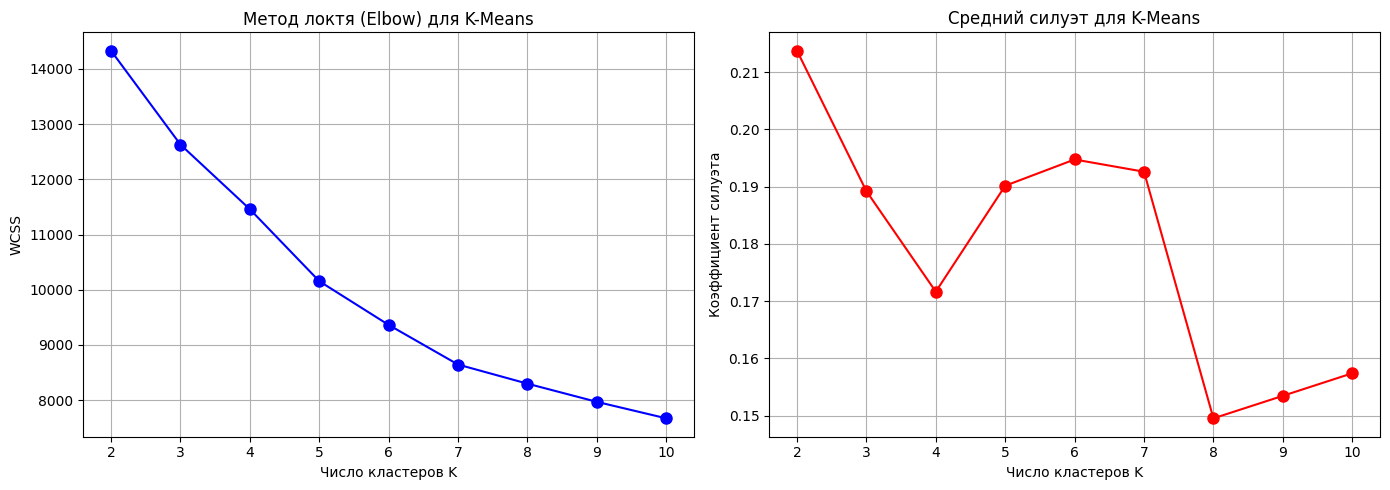

In [6]:
# Визуализация: метод локтя (WCSS) и средний силуэт.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [7]:
# Выбор оптимального K по силуэту
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Оптимальное число кластеров по силуэту: {optimal_k}")

Оптимальное число кластеров по силуэту: 2


In [8]:
#  Обучение финальной модели K‑Means с выбранным К
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

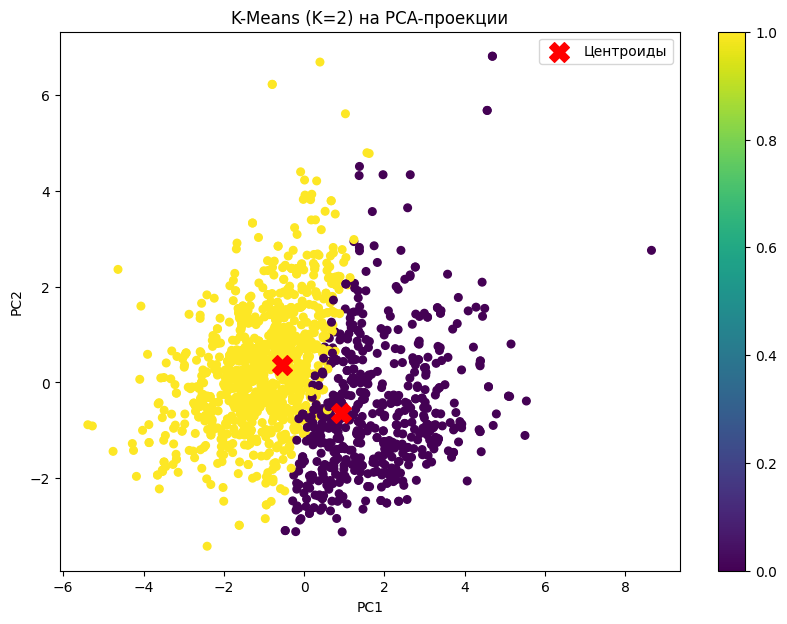

In [9]:
# Визуализация кластеров с помощью PCA (2 компоненты)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

In [10]:
# Силуэт финальной модели
final_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score финальной модели: {final_silhouette:.3f}")

Silhouette Score финальной модели: 0.214


## Часть 2. DBSCAN

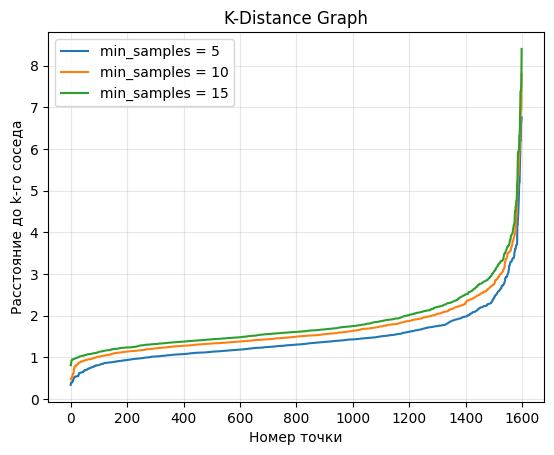

In [11]:
# 1. Постройте k‑distance graph для min_samples = 5, 10, 15

for min_s in [5, 10, 15]:

    # Находим расстояния до k-го соседа для каждой точки
    neighbors = NearestNeighbors(n_neighbors=min_s)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, _ = neighbors_fit.kneighbors(X_scaled)

    k_distances = np.sort(distances[:, min_s-1])

    plt.plot(k_distances, label=f'min_samples = {min_s}')

plt.xlabel('Номер точки')
plt.ylabel('Расстояние до k-го соседа')
plt.title('K-Distance Graph')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# 2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15)
# найдите параметры, дающие максимальный силуэт (число кластеров ≥ 2, шум не более 80% данных).

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1]
min_samples_values = [5, 10, 15]

# Переменные для запоминания лучшего результата
best_score = -1
best_eps = None
best_min_samples = None

for eps in eps_values:
    for min_s in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(X_scaled)

        # сколько кластеров и сколько шума
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = n_noise / len(labels) * 100

        # Пропускаем, если кластеров меньше 2 или шума больше 80%
        if n_clusters < 2 or noise_percent > 80:
            continue

        # silhouette (для точек не-шума)
        if n_clusters >= 2:
            mask = labels != -1
            if mask.sum() > 10:
                score = silhouette_score(X_scaled[mask], labels[mask])

                # Если результат лучше предыдущего — запоминаем
                if score > best_score:
                    best_score = score
                    best_eps = eps
                    best_min_samples = min_s

print(f"Лучшие параметры: eps={best_eps}, min_samples={best_min_samples}")
print(f"Silhouette Score: {best_score:.3f}")

Лучшие параметры: eps=1.1, min_samples=10
Silhouette Score: 0.246


In [13]:
# 3. Обучите DBSCAN с лучшими параметрами.
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)

clusters = dbscan_final.fit_predict(X_scaled)

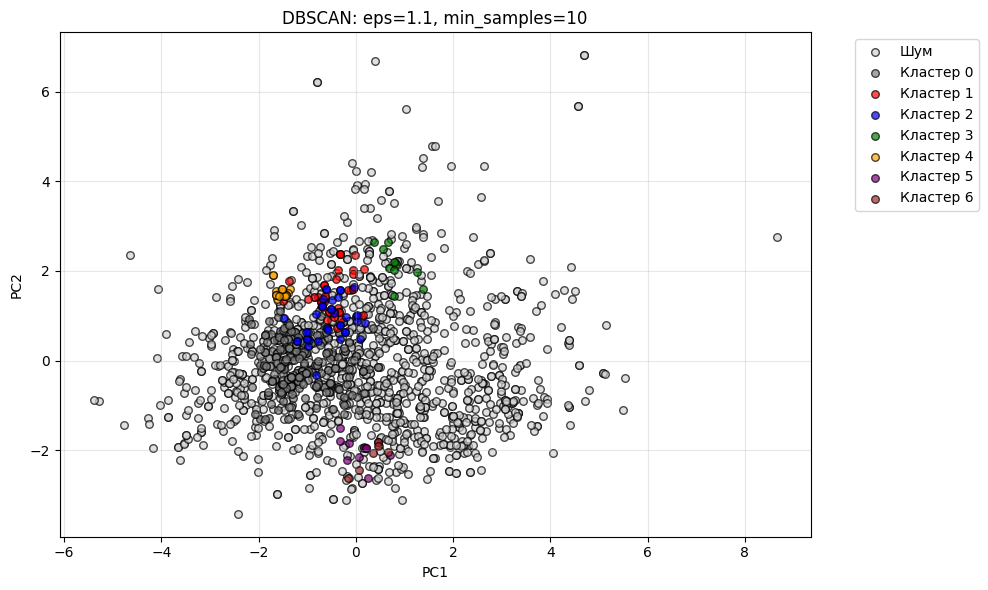

In [14]:
# 4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(10, 6))

# шум — серый, кластеры — разные цвета
colors = ['gray', 'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink']

for label in sorted(set(clusters)):
    mask = clusters == label
    color = colors[label % len(colors)] if label >= 0 else 'lightgray'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color], label=f'Кластер {label}' if label >= 0 else 'Шум',
                s=30, alpha=0.7, edgecolors='black')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN: eps={best_eps}, min_samples={best_min_samples}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**- Почему для DBSCAN критически важно масштабировать данные?**

Для DBSCAN важно масштабировать данные, потому что он считает расстояния между точками. Если один признак измеряется в десятках, а другой — в десятых, то первый будет весить гораздо. Масштабирование делает все признаки одинаково важными

**- Что будет при слишком маленьком `eps`? Слишком большом?**

При слишком маленьком eps кластеры не образуются, почти все точки становятся шумом. При слишком большом, все точки -- в одном кластере, теряется смысл кластеризации

**- Что означают точки с меткой `-1`?**

Точки с меткой -1 это шум (outlier). Они не попали в радиус eps ни к одной группе, и сами не набрали достаточно соседей (min_samples), чтобы стать центром кластера.

**- Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?**

Кластеры DBSCAN могут быть любой формы, он сам определяет число кластеров, отдельно выделяет шум  



## Часть 3. OPTICS

In [15]:
# 1. Обучите OPTICS на тех же данных с параметрами:
#    - `min_samples = 10`
#    - `xi = 0.05`
#    - `min_cluster_size = 0.05`

optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
labels_optics = optics.fit_predict(X_scaled)

In [16]:
# 2. Выведите:
#    - количество найденных кластеров
#    - количество шумовых точек
#    - коэффициент силуэта

unique_labels = set(labels_optics)
n_clusters_optics = len(unique_labels - {-1})
n_noise = list(labels_optics).count(-1)

# силуэт (только если >1 кластер)
if n_clusters_optics > 1:
    silhouette_optics = silhouette_score(X_scaled, labels_optics)
else:
    silhouette_optics = -1

print(f"Кластеров: {n_clusters_optics}, шума: {n_noise}, silhouette: {silhouette_optics:.3f}")

Кластеров: 1, шума: 0, silhouette: -1.000


/tmp/ipykernel_39198/1194775659.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)


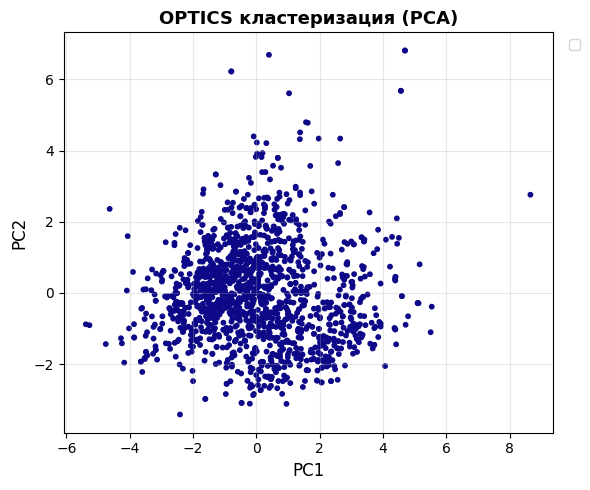

In [17]:
# визуализация

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_optics, cmap='plasma', s=10)

# Оформление
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title(f'OPTICS кластеризация (PCA)',
          fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

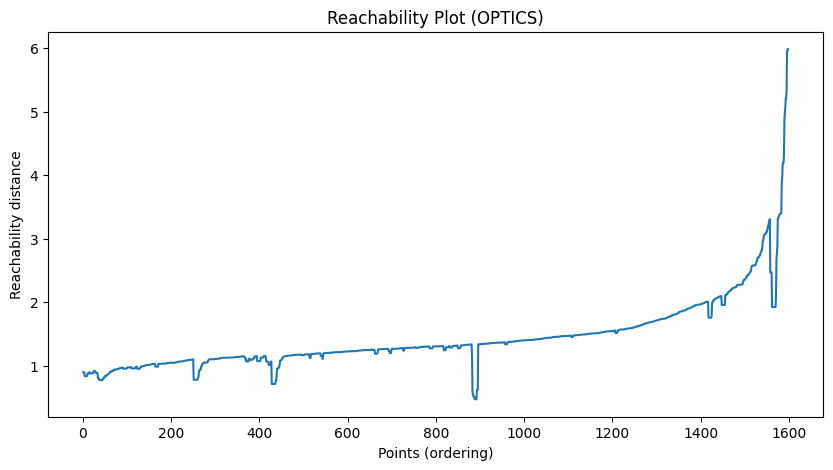

In [18]:
reachability = optics.reachability_[optics.ordering_]
labels = labels_optics[optics.ordering_]

plt.figure(figsize=(10,5))
plt.plot(reachability)
plt.title("Reachability Plot (OPTICS)")
plt.ylabel("Reachability distance")
plt.xlabel("Points (ordering)")
plt.show()

In [19]:
from sklearn.cluster import DBSCAN
import time

# DBSCAN
start = time.time()
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
db_time = time.time() - start

# OPTICS
start = time.time()
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
opt_labels = optics.fit_predict(X_scaled)
opt_time = time.time() - start

print("DBSCAN time:", db_time)
print("OPTICS time:", opt_time)

DBSCAN time: 0.10535693168640137
OPTICS time: 4.03983736038208


**Ответьте на вопросы (письменно, развёрнуто):**
**- Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.**

В DBSCAN нужно заранее задать eps, в OPTICS этот параметр не фиксируется, что делает OPTICS более устойчивым к данным с разной плотностью. DBSCAN сразу выдает разбиение; OPTICS строит reachability plot, из которого можно извлекать кластеры при разных масштабах.

**- Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?**

`xi` — определяет, насколько резко должна измениться плотность, чтобы алгоритм выделил кластеры. Если маленький `xi`, кластеров больше, они меньше, чувствителен к шуму.

**- В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.**

Если данные имеют кластеры разной плотности. Например, поиск ботов среди аккаунтов пользователей соц.сетей по их активности в определенный период времени. Активность ботов сильно выше=плотнее, активность настоящих людей меньше - кластеры более разреженные.

**- Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).**

DBSCAN time: 0.09364128112792969
OPTICS time: 5.700875759124756

DBSCAN быстрее, потому что OPTICS строит иерархию, считает reachability distances

**- Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?**

Судя по моему блокноту лучше сработал K‑Means, но возможно потому, что в остальных методах есть ошибки. С другой стороны, на Reachability Plot (OPTICS) тоже хорошо выделяются кластеры.